## Validation Plot Development

In [26]:
from pathlib import Path
import treedata as td
import pycea as py
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns

from devmap.config import edit_palette, discrete_cmap, set_theme
from devmap.utils import save_plot
plots_path = Path("/lab/solexa_weissman/wcolgan/devmap-paper/validation/plots")

set_theme()

# autoreload
%load_ext autoreload
%autoreload 2

## Characters and zoom

In [3]:
def plot_grouped_characters(tdata,ax = None,width = .1,label = False,offset = .05):
    """Plot allele table grouped by integration"""
    if ax is None:
        ax = plt.gca()
    tdata.obs = tdata.obs.merge(tdata.obsm["characters"].astype(str),left_index=True,right_index=True)
    ids = tdata.obsm["characters"].columns.str.split("-").str[0].str.replace("intID","").unique()
    ids = sorted(ids,key = lambda x: int(x))
    for i,id in enumerate(ids):
        gap = offset if i == 0 else width/2
        py.pl.annotation(tdata,keys=[f"intID{id}-RNF2",f"intID{id}-HEK3",f"intID{id}-EMX1"],border_width=.3,
                            label = id,width=width,gap = gap,palette = edit_palette,ax = ax, legend = False)
    tdata.obs = tdata.obs.drop(columns = tdata.obsm["characters"].columns)
    ax.tick_params(axis='x', pad=0)

Tree with characters

In [ ]:
tdata = td.read_h5td("/lab/solexa_weissman/wcolgan/devmap-paper/processing/embryos/e9.5_r3/e9.5_r3_tree.h5td")

In [5]:
leaves = py.get.leaves(tdata)
leaves =  [item for sublist in leaves.values() for item in sublist]
tdata = tdata[leaves].copy()

In [6]:
for clone,tree in tdata.obst.items():
    nx.set_edge_attributes(tree,clone,name = "clone")

In [228]:
stump = td.read_h5td("/lab/solexa_weissman/wcolgan/devmap-paper/processing/embryos/slow_r2/slow_r2_stump.h5td")

In [229]:
stump

TreeData object with n_obs × n_vars = 6764 × 0
    obs: 'tree', 'clade', 'clone', 'depth'
    uns: 'characters_colors', 'clade_colors', 'doublet_colors'
    obsm: 'characters'
    obst: 'SLOW-R2-C1', 'SLOW-R2-C2', 'SLOW-R2-C3', 'SLOW-R2-C4', 'SLOW-R2-C5', 'SLOW-R2-C6', 'SLOW-R2-C7', 'SLOW-R2-C8', 'SLOW-R2-C9', 'SLOW-R2-C10', 'SLOW-R2-C11', 'SLOW-R2-C12', 'SLOW-R2-C13', 'SLOW-R2-C14', 'SLOW-R2-C15', 'SLOW-R2-C16', 'SLOW-R2-C17', 'SLOW-R2-C18', 'SLOW-R2-C19', 'SLOW-R2-C20', 'SLOW-R2-C21', 'SLOW-R2-C22', 'SLOW-R2-C23', 'SLOW-R2-C24', 'SLOW-R2-C25', 'SLOW-R2-C26', 'SLOW-R2-C27', 'SLOW-R2-C28', 'SLOW-R2-C29', 'SLOW-R2-C30', 'SLOW-R2-C31', 'SLOW-R2-C32', 'SLOW-R2-C33', 'SLOW-R2-C34', 'SLOW-R2-C35', 'SLOW-R2-C36', 'SLOW-R2-C37', 'SLOW-R2-C38', 'SLOW-R2-C39', 'SLOW-R2-C40', 'SLOW-R2-C41', 'SLOW-R2-C42', 'SLOW-R2-C43', 'SLOW-R2-C44', 'SLOW-R2-C45', 'SLOW-R2-C46', 'SLOW-R2-C47', 'SLOW-R2-C48', 'SLOW-R2-C49', 'SLOW-R2-C50', 'SLOW-R2-C51', 'SLOW-R2-C52', 'SLOW-R2-C53', 'SLOW-R2-C54', 'SLOW-R2-C55'

In [125]:
tdata.shape

(321755, 0)

In [31]:
tdata.obs["order"] = np.arange(tdata.shape[0])
zoom_center = 112000
zoom_width = 2000
tdata.obs["zoom"] = tdata.obs["order"].apply(lambda x: abs(x - zoom_center) < zoom_width/2)

AttributeError: 'DataFrame' object has no attribute 'zoom'

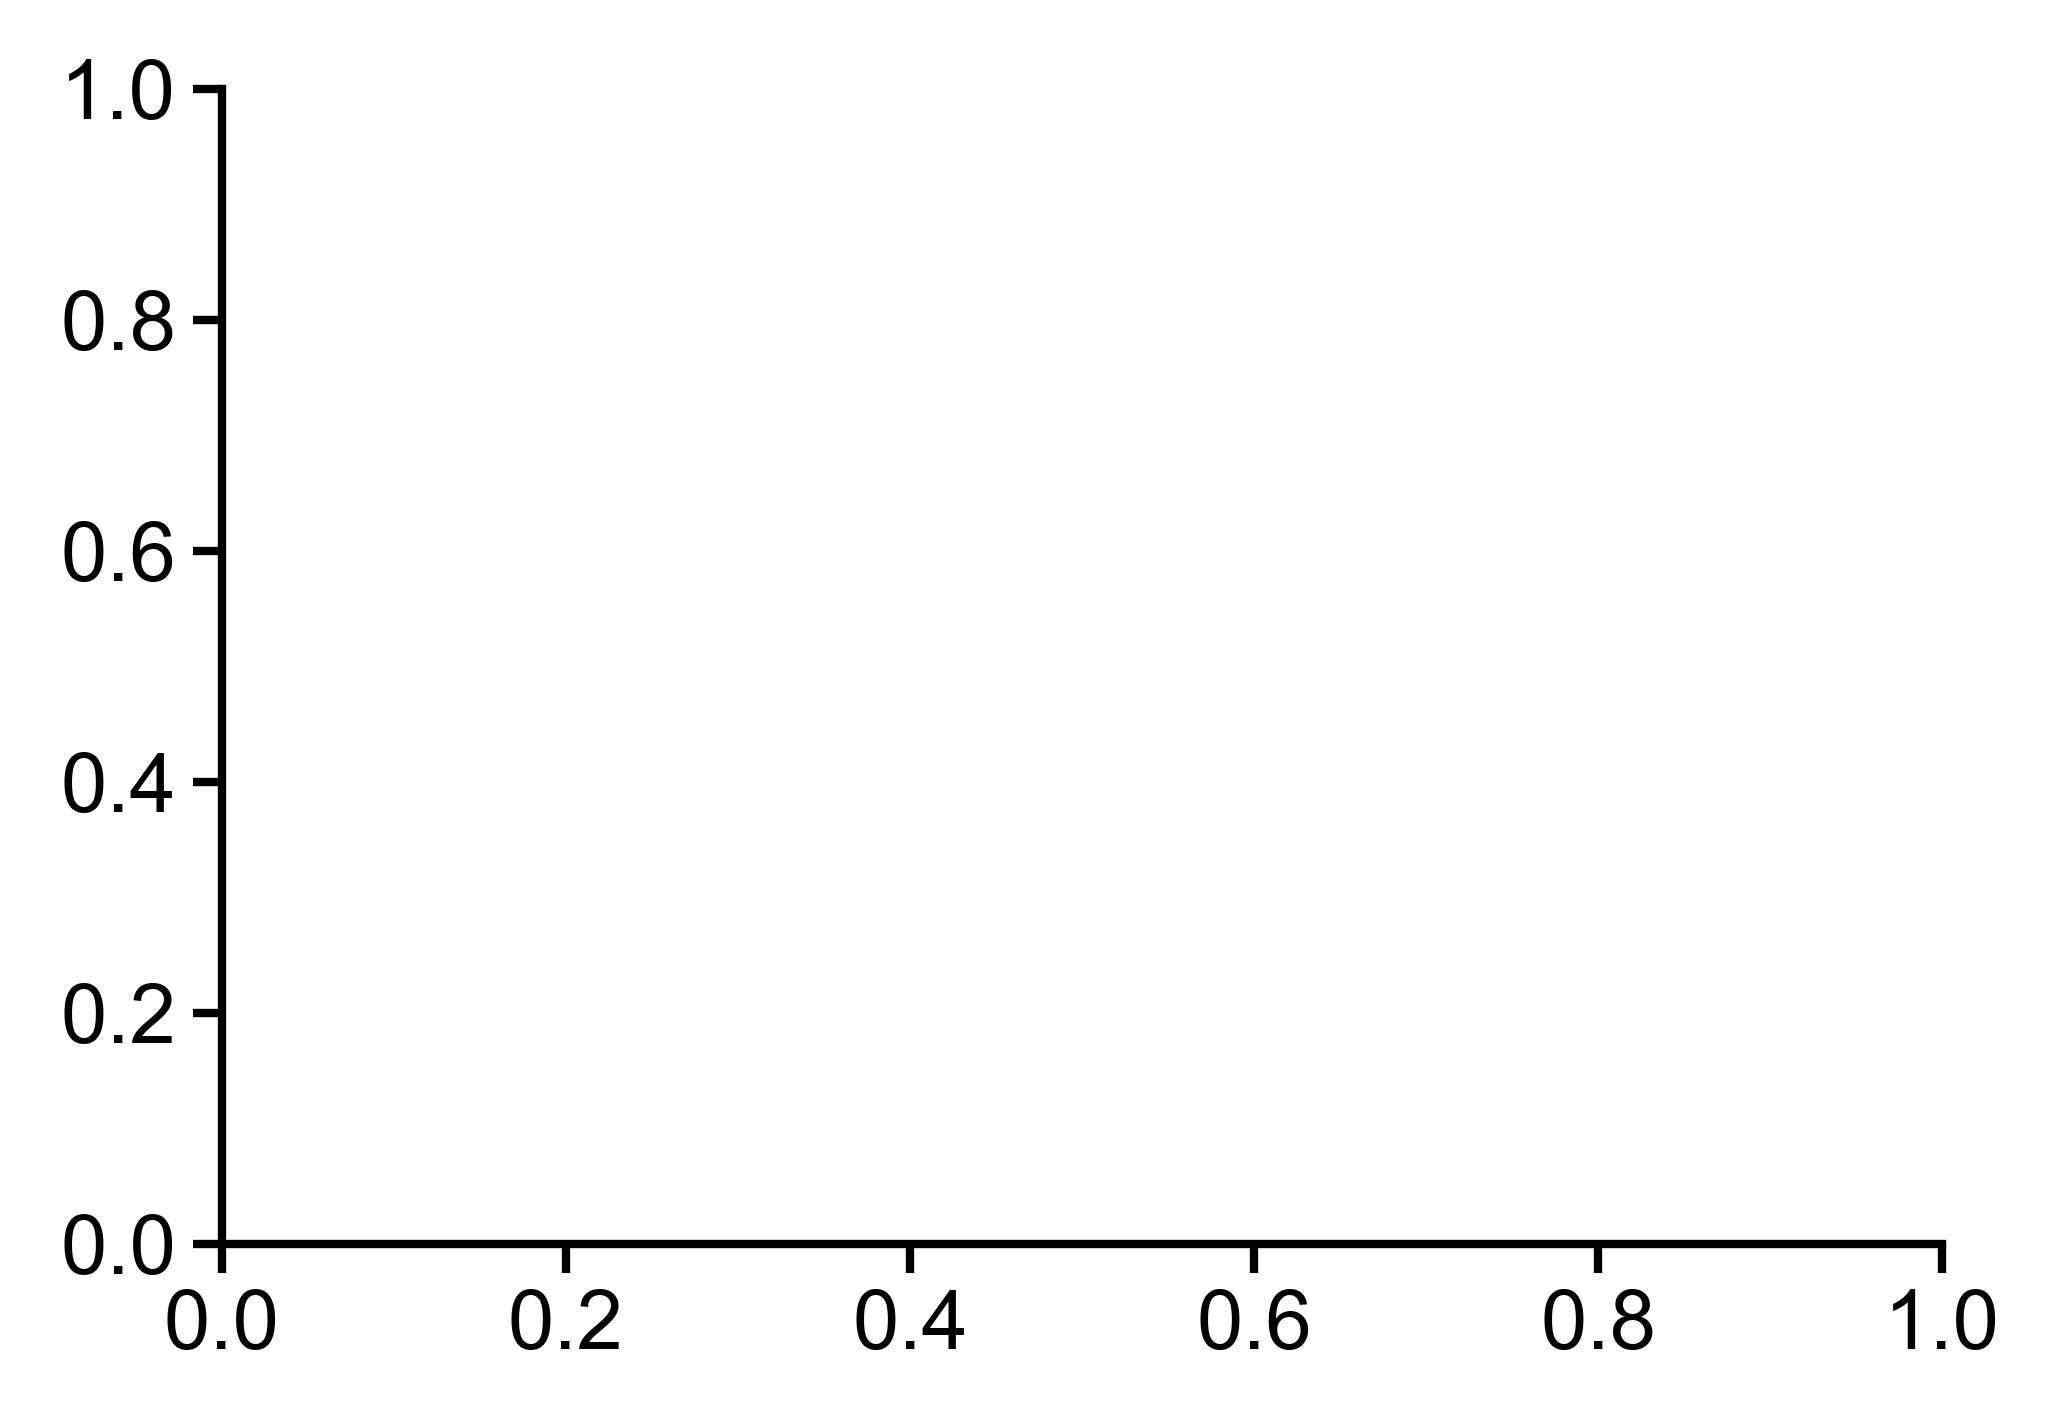

In [231]:
fig, ax = plt.subplots(figsize=(3.7,2.5), dpi = 600)
py.pl.branches(tdata[tdata.obs.zoom],depth_key ="time", ax = ax, linewidth = .2, color = "clone", legend = False)
plot_grouped_characters(tdata[tdata.obs.zoom],ax = ax,width = .06,label = True,offset = .02)
# decrease x tick font size
ax.tick_params(axis='x', labelsize=6.5)
save_plot(plots_path / "e9.5_characters_zoom.svg", fig, rasterize=True)

In [145]:
print(tdata.obs.clone.value_counts())

clone
E9.5-R3-C1    128892
E9.5-R3-C2    125944
E9.5-R3-C3     37639
E9.5-R3-C4     29280
Name: count, dtype: int64


/lab/solexa_weissman/wcolgan/tools/miniconda3/envs/devmap/lib/python3.11/site-packages/pycea/utils.py:180: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if key in tdata.obs_keys() and (slot is None or slot == "obs"):


<Axes: >

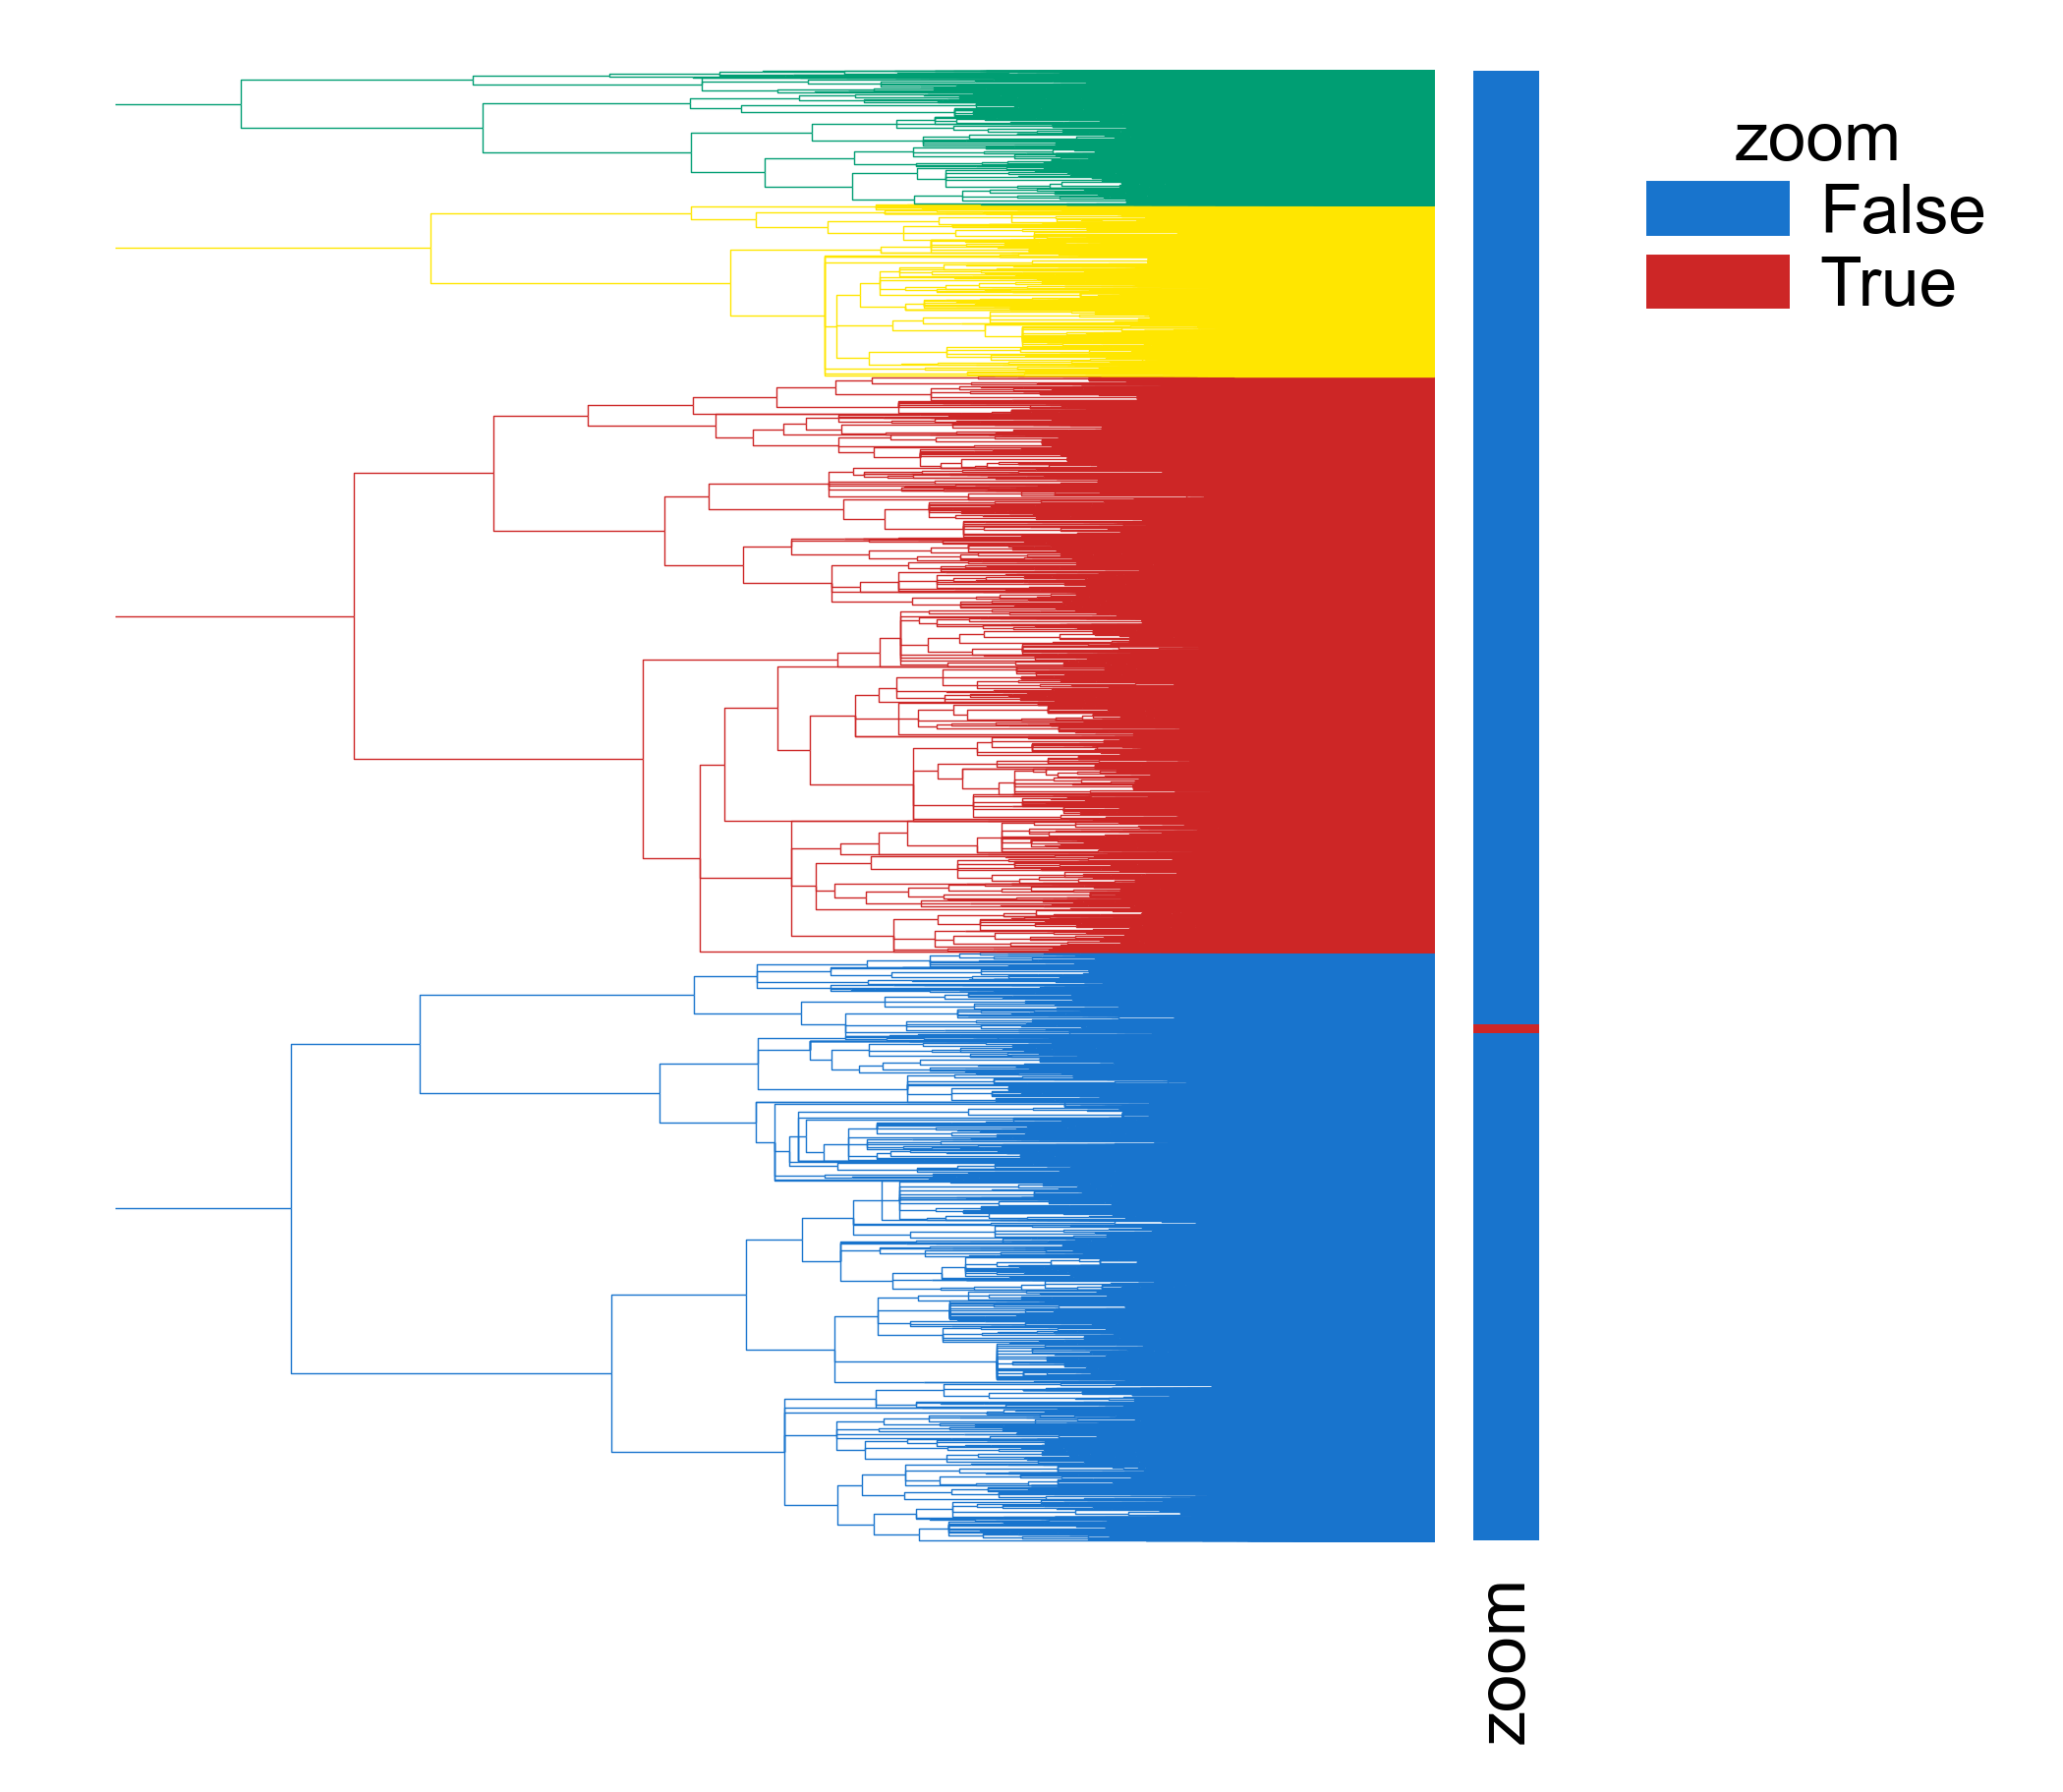

In [28]:
fig, ax = plt.subplots(figsize=(4,4), dpi = 500)
py.pl.branches(tdata,depth_key ="time", ax = ax, linewidth = .2, color = "clone", legend = False)
py.pl.annotation(tdata,keys = "zoom")

/lab/solexa_weissman/wcolgan/tools/miniconda3/envs/devmap/lib/python3.11/site-packages/pycea/utils.py:180: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if key in tdata.obs_keys() and (slot is None or slot == "obs"):
/lab/solexa_weissman/wcolgan/tools/miniconda3/envs/devmap/lib/python3.11/site-packages/pycea/utils.py:180: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if key in tdata.obs_keys() and (slot is None or slot == "obs"):
/lab/solexa_weissman/wcolgan/tools/miniconda3/envs/devmap/lib/python3.11/site-packages/pycea/utils.py:180: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if key i

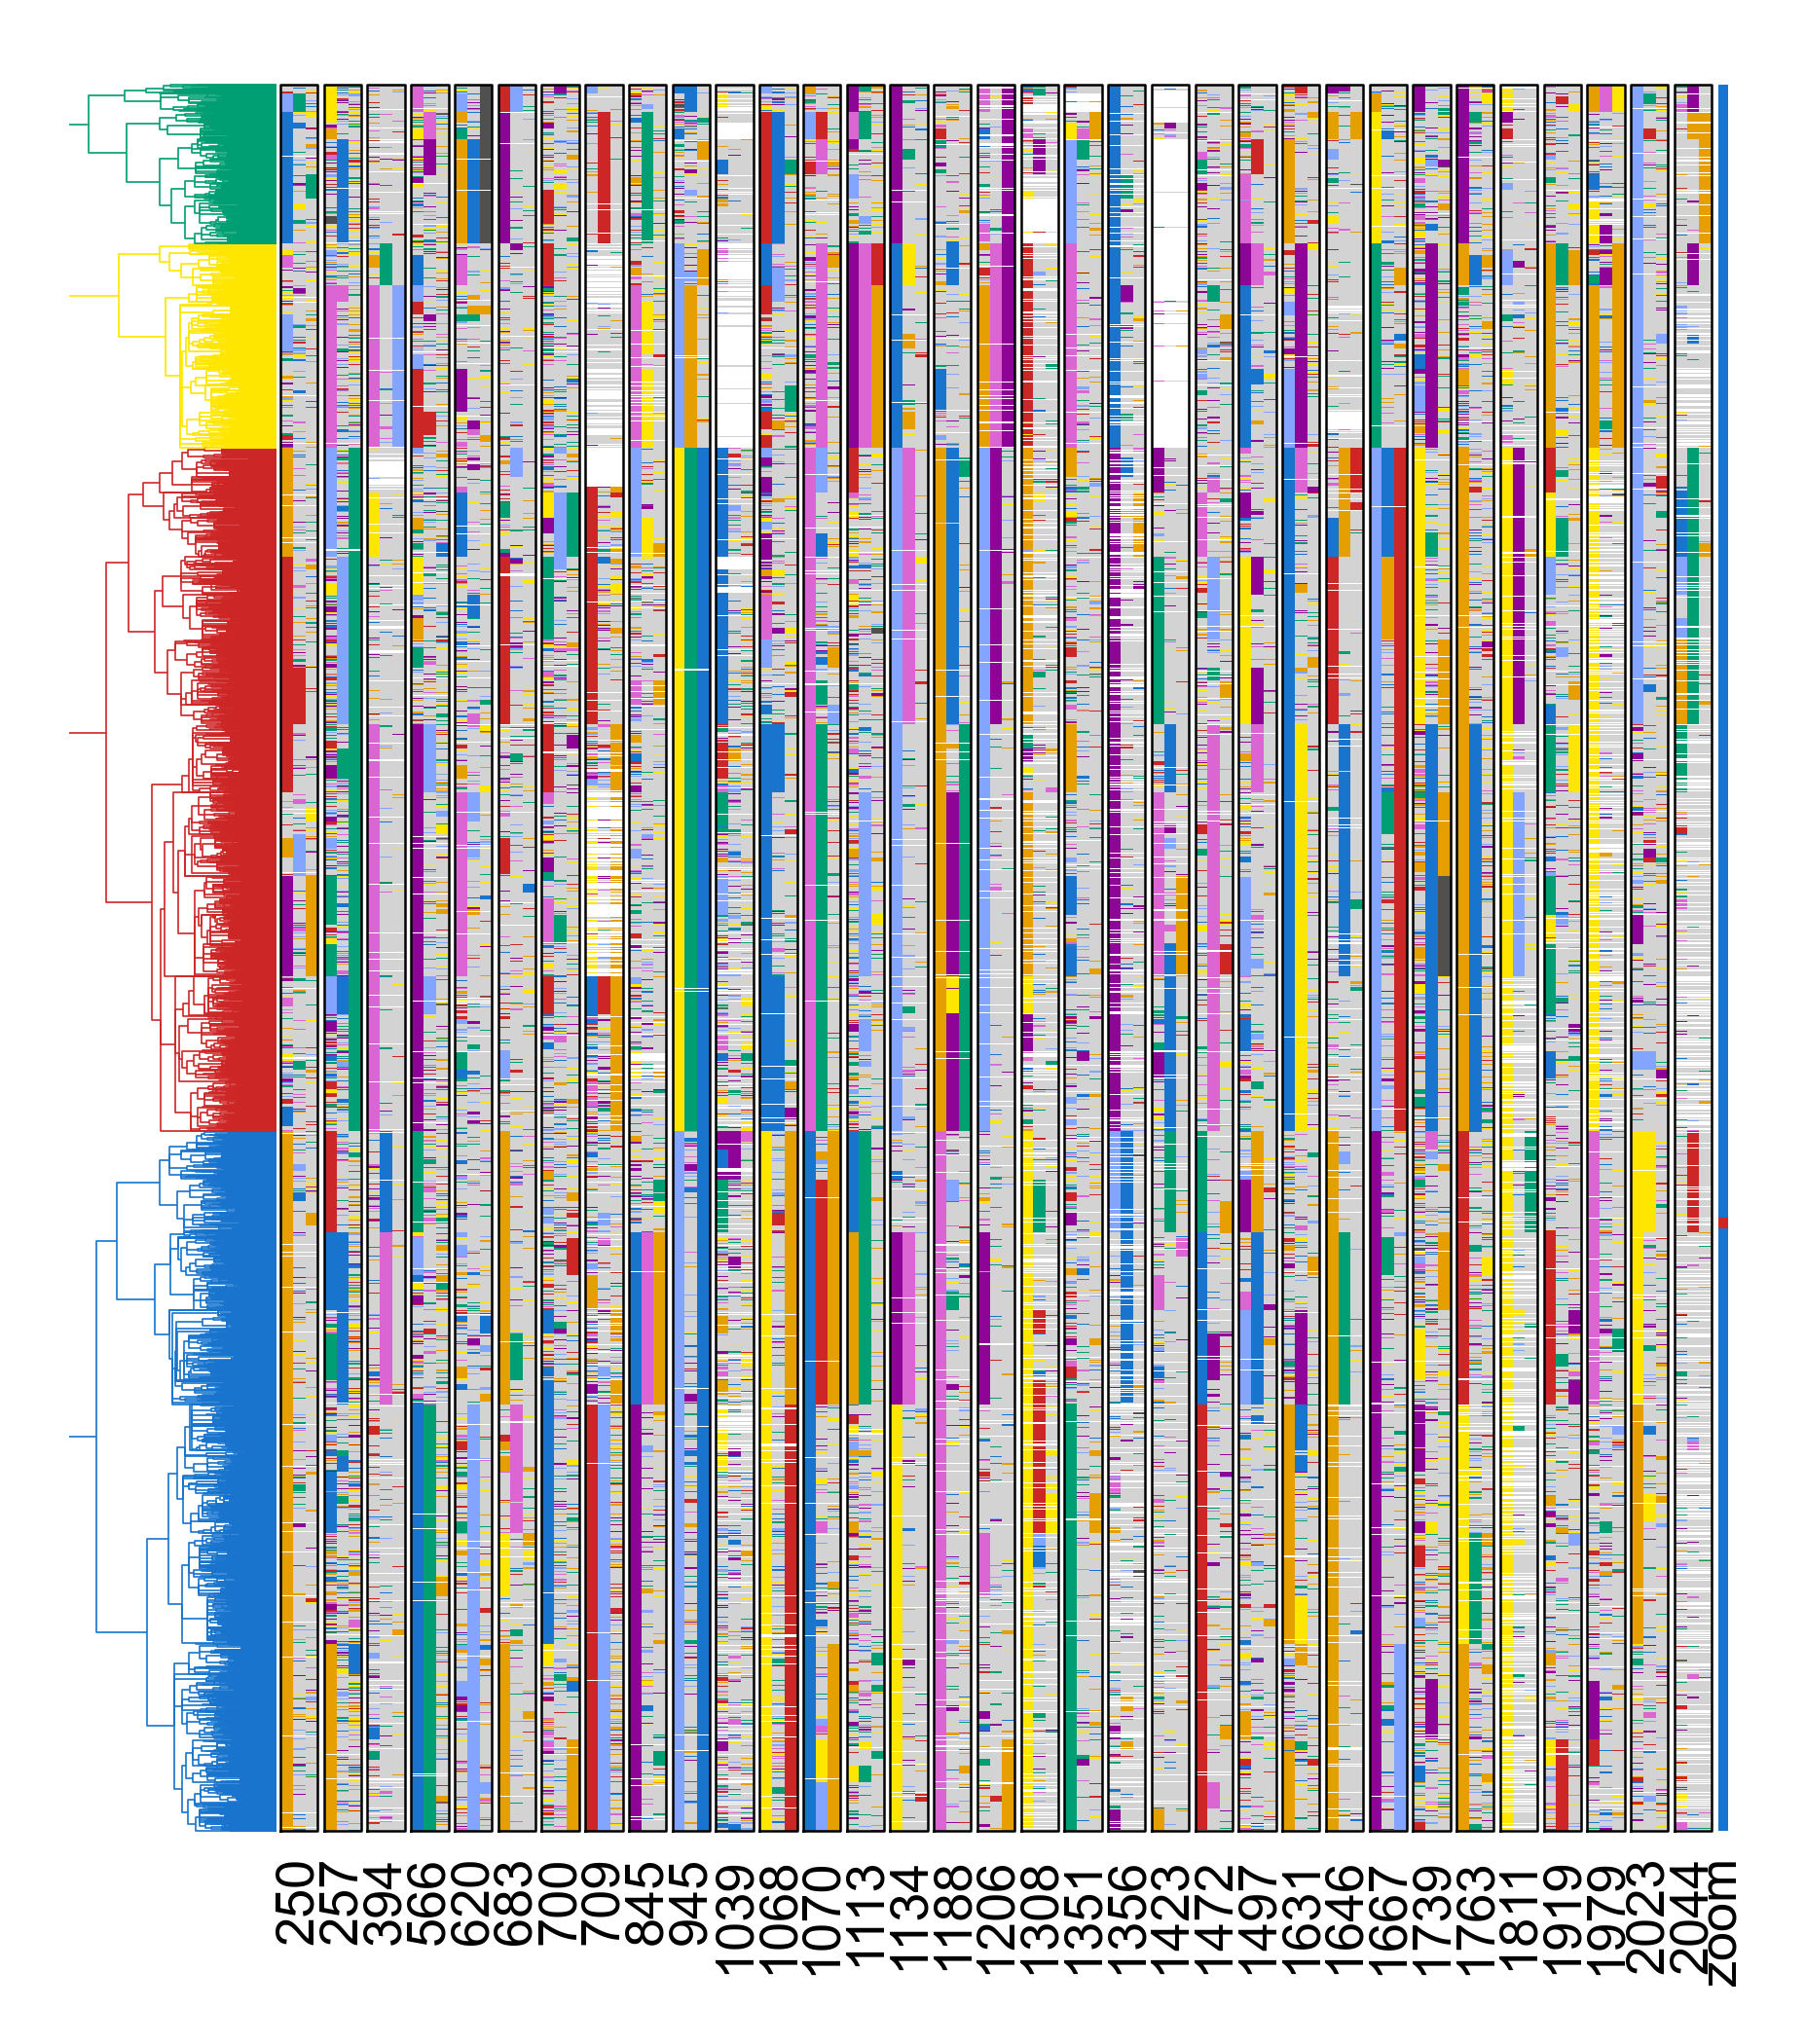

In [36]:
fig, ax = plt.subplots(figsize=(3.7,4), dpi = 600)
py.pl.branches(tdata,depth_key ="time", ax = ax, linewidth = .2, color = "clone", legend = False)
plot_grouped_characters(tdata,ax = ax,width = .06,label = True,offset = .02)
py.pl.annotation(tdata,keys = "zoom", legend = False)
# decrease x tick font size
ax.tick_params(axis='x', labelsize=6.5)
save_plot(plots_path / "e9.5_characters.svg", fig, rasterize=True)

branches supported by edit by depth


percent of cell with unique state
percent of branches supported by an edit
average depth of tree


## Biases

In [4]:
tree = td.read_h5td("/lab/solexa_weissman/wcolgan/devmap-paper/processing/embryos/e9.5_r3/e9.5_r3_tree.h5td")
counts = td.read_h5td("/lab/solexa_weissman/wcolgan/devmap-paper/processing/embryos/e9.5_r3/e9.5_r3_counts.h5td")

In [15]:
print("normalizing")
sc.pp.normalize_total(counts, target_sum=2e4)
print("log1p")
sc.pp.log1p(counts)

normalizing
log1p


In [ ]:
labels = pd.read_csv("/lab/solexa_weissman/wcolgan/devmap-paper/annotation/data/label_transfer.csv",index_col=0)

/tmp/ipykernel_1849116/1236769769.py:1: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  labels = pd.read_csv("/lab/solexa_weissman/wcolgan/devmap-paper/annotation/data/label_transfer.csv",index_col=0)


In [31]:
tree.obs["pe_expr"] = sc.get.obs_df(counts, "PE2maxGFP")

In [14]:
tree.obs["pe_counts"] = sc.get.obs_df(counts, "PE2maxGFP")
tree.obs["cell_type"] = labels["v2"]

In [45]:
df.sort_values("edit_frac", ascending=False)

,cell_type,pe_counts,edit_frac,pe_expr
64,venous endothelial cell,6.000000,0.560000,3.094437
35,notochordal cell,6.890957,0.505575,2.683519
2,arterial endothelial cell,9.828571,0.493690,3.003747
44,primitive macrophage,12.586855,0.493182,2.876870
10,endothelial cell,13.950499,0.492547,3.179917
...,...,...,...,...
12,epibranchial placode,8.351839,0.452834,2.811196
61,trigeminal sensory neuron,11.522727,0.451770,2.999959
36,olfactory placode,9.111772,0.450892,2.846218
37,olfactory sensory neuron,9.487804,0.450331,2.956783


In [39]:
df = tree.obs.query("type == 'donor'").groupby("cell_type").agg({"pe_counts": "mean", "edit_frac": "mean","pe_expr": "mean"}).reset_index()

<Axes: xlabel='pe_expr', ylabel='edit_frac'>

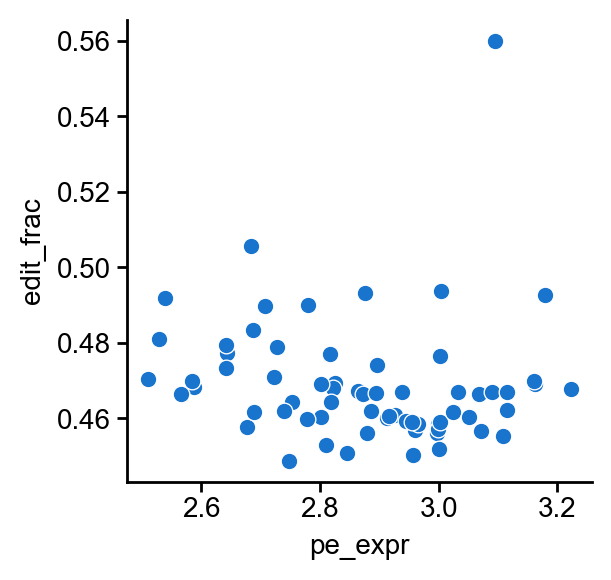

In [42]:
sns.scatterplot(data = df,x = "pe_expr",y = "edit_frac")

Text(0.5, 0, 'Cell type mean PE2maxGFP expression')

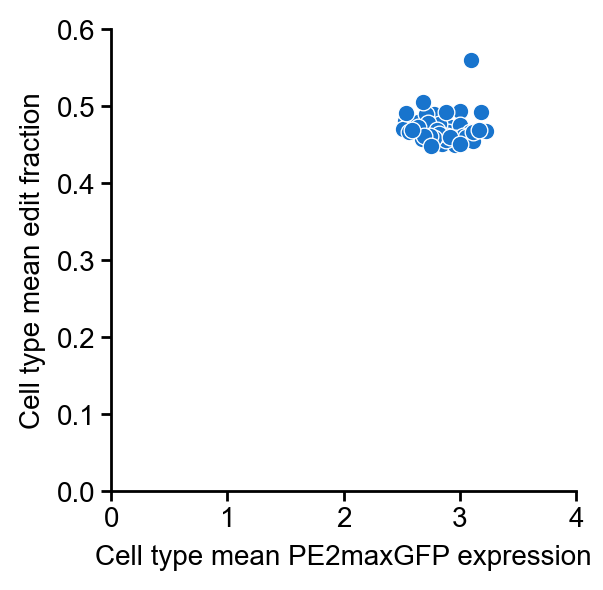

In [50]:
sns.scatterplot(data = df,x = "pe_expr",y = "edit_frac")
plt.xlim(0,4)
plt.ylim(0,.6)
plt.ylabel("Cell type mean edit fraction")
plt.xlabel("Cell type mean PE2maxGFP expression")

(0.0, 0.6)

/lab/solexa_weissman/wcolgan/tools/miniconda3/envs/devmap/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 28.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


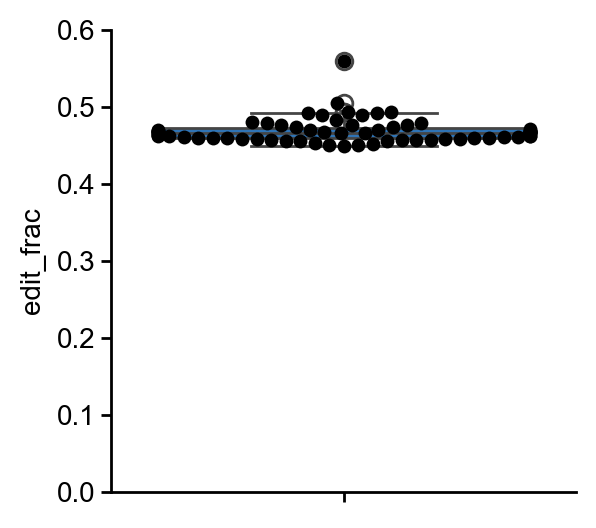

In [57]:
sns.boxplot(data = df,y = "edit_frac")
sns.swarmplot(data = df,y = "edit_frac", color = "black", alpha = 1)
plt.ylim(0,.6)

(0.0, 0.6)

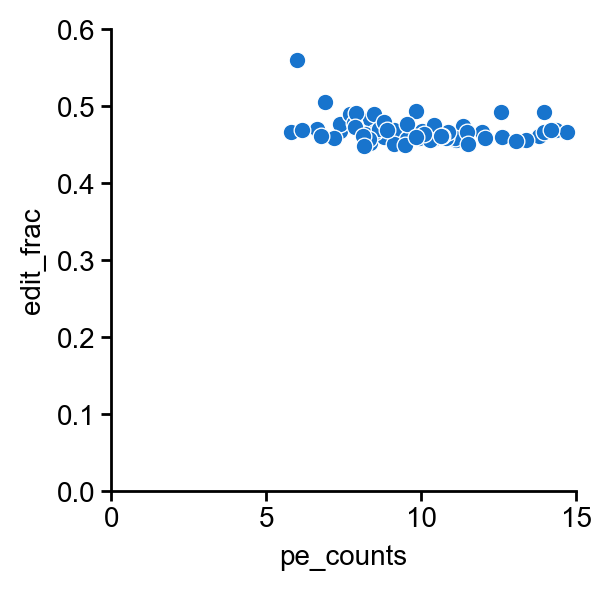

In [48]:
sns.scatterplot(data = df,x = "pe_counts",y = "edit_frac")
plt.xlim(0,15)
plt.ylim(0,.6)

In [23]:
tree

TreeData object with n_obs × n_vars = 321755 × 0
    obs: 'capture', 'cellBC', 'embryo', 'type', 'n_genes_by_counts', 'total_counts', 'detection_rate', 'clade', 'clone', 'tree', 'pe_counts', 'cell_type'
    uns: 'characters_colors', 'clade_characters', 'clade_colors', 'doublet_colors'
    obsm: 'characters'
    obst: 'E9.5-R3-C1', 'E9.5-R3-C2', 'E9.5-R3-C3', 'E9.5-R3-C4'

In [24]:
n_unedited = (tree.obsm['characters'] == "*").sum(axis=1)
n_detected = (tree.obsm["characters"] != "-").sum(axis=1)
tree.obs["edit_frac"] = (n_detected - n_unedited) / n_detected

<Axes: xlabel='pe_expr', ylabel='edit_frac'>

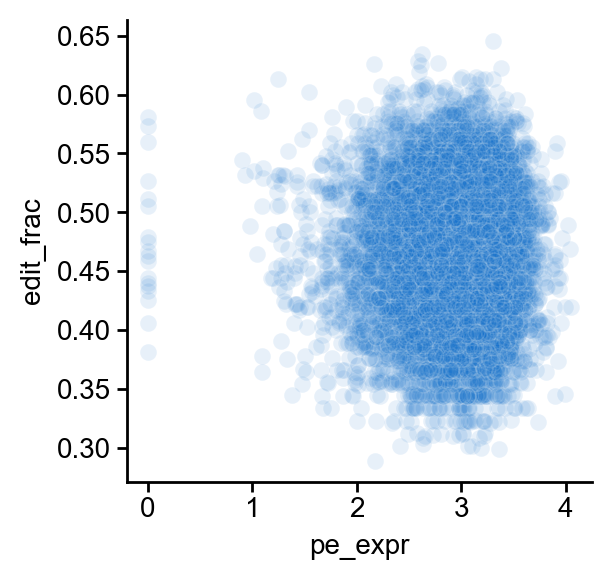

In [32]:
sns.scatterplot(data = tree.obs.sample(n=10000),x = "pe_expr",y = "edit_frac", alpha = .1)

<Axes: xlabel='pe_expr', ylabel='edit_frac'>

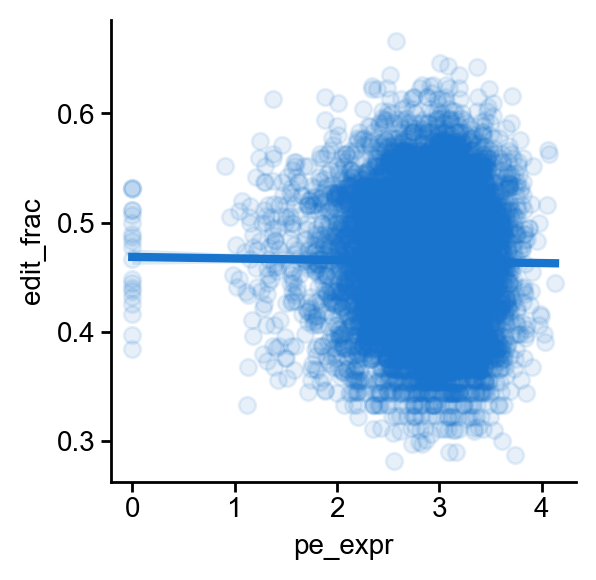

In [47]:
sns.regplot(data = tree.obs.sample(n=10000),x = "pe_expr",y = "edit_frac", scatter_kws=dict(alpha=.1))

(0.0, 0.7)

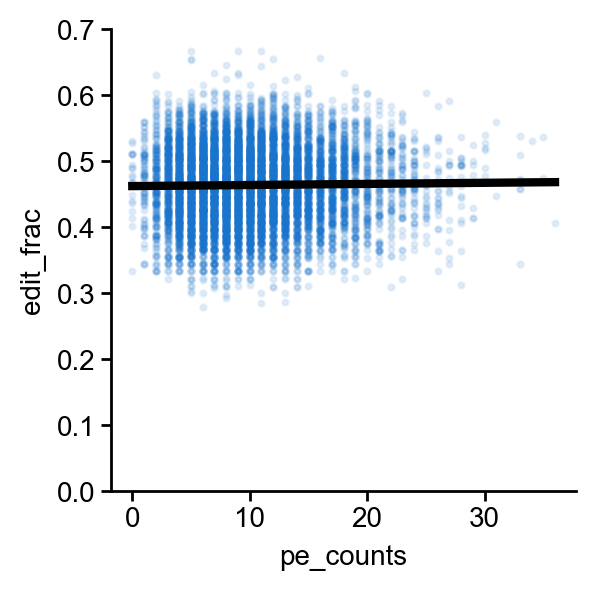

In [71]:
sns.regplot(data = tree.obs.sample(n=10000),x = "pe_counts",y = "edit_frac", scatter_kws=dict(alpha=.1,s = 4), line_kws=dict(color="black"))
#sns.kdeplot(data = tree.obs.sample(n=10000),x = "pe_counts",y = "edit_frac", cmap = "Reds", fill = True, thresh = 0.05)
plt.ylim(0,.7)

<Axes: xlabel='pe_counts', ylabel='edit_frac'>

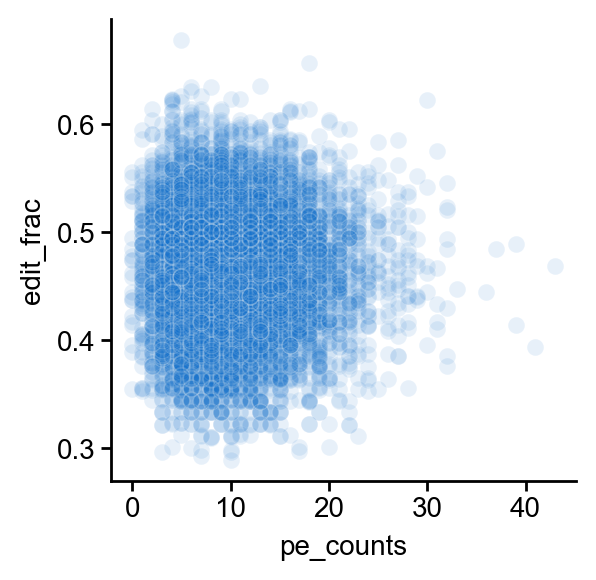

In [30]:
sns.scatterplot(data = tree.obs.sample(n=10000),x = "pe_counts",y = "edit_frac", alpha = .1)

In [51]:
clone_stats = tree.obs.query("type == 'donor'").groupby("clone").agg({"pe_counts": "mean", "edit_frac": "mean","pe_expr": "mean"}).reset_index()

/tmp/ipykernel_1849116/685637656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_stats = tree.obs.query("type == 'donor'").groupby("clone").agg({"pe_counts": "mean", "edit_frac": "mean","pe_expr": "mean"}).reset_index()


In [52]:
clone_stats 

,clone,pe_counts,edit_frac,pe_expr
0,E9.5-R3-C1,10.064232,0.448244,2.896754
1,E9.5-R3-C2,10.044528,0.496234,2.890531
2,E9.5-R3-C3,9.987167,0.460715,2.864945
3,E9.5-R3-C4,9.878757,0.400220,2.859924


In [ ]:
sns.boxplot(data = df,y = "edit_frac")
sns.swarmplot(data = df,y = "edit_frac", color = "black", alpha = 1)
plt.ylim(0,.6)

In [3]:
## Growth kinetics

## Number of extant cells over time

In [150]:
embryos = ["E7.5-R1","E7.5-R2","E7.5-R3","E8.0-R1","E8.0-R2","E8.0-R3","E8.5-R1",
"E8.5-R2","E8.5-R3","E9.0-R1","E9.0-R2","E9.0-R3","E9.5-R1","E9.5-R2","E9.5-R3","E10.0-R1"]
embryo_palette = dict(zip(embryos,reversed(discrete_cmap[17][1:17])))

In [ ]:
tdata = td.read_h5td("/lab/wcolgan_scratch/final_topology.h5td")
tdata.obs["embryo"] = tdata.obs["tree"].str.split("-C").str[0]
tdata.obs["stage"] = tdata.obs["tree"].str.split("-").str[0]

In [11]:
e95_tdata = tdata[tdata.obs.stage == "E9.5"].copy()

In [153]:
n_extant = py.tl.n_extant(tdata,bins = np.arange(0,10.5,.5),copy = True, depth_key="time")

In [154]:
saved_n_extant = n_extant.copy()

In [215]:
n_extant["embryo"] = n_extant["tree"].str.split("-C").str[0]
n_extant = n_extant.groupby(['time','embryo']).agg({'n_extant':'sum'}).reset_index()
n_extant["timepoint"] = n_extant["embryo"].str.split("-").str[0].str.replace("E", "").astype(float)
n_extant["stage"] = n_extant["embryo"].str.split("-R").str[0]

In [180]:
from devmap.config import stage_palette

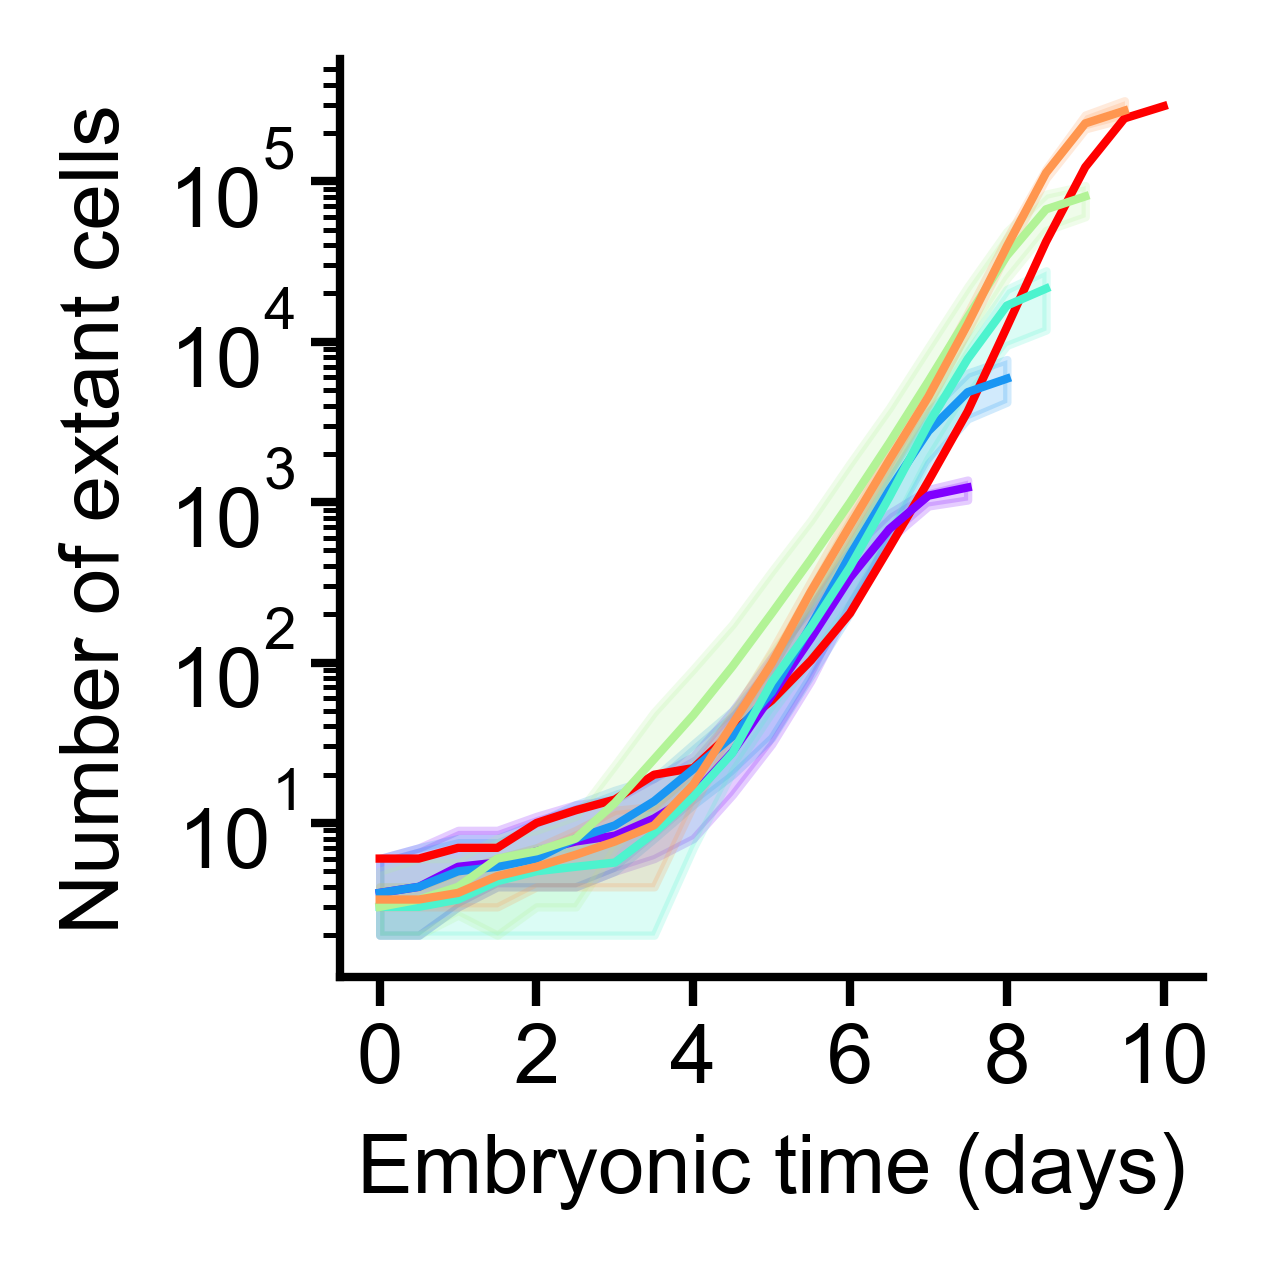

In [183]:
fig, ax = plt.subplots(figsize=(2,2),dpi=600, layout = "constrained")
sns.lineplot(data=n_extant.query("time <= timepoint"), x="time", y="n_extant", hue="stage", legend = False, 
             linewidth = 1, palette = stage_palette)
plt.xticks([0,2,4,6,8,10])
plt.xlabel("Embryonic time (days)")
plt.ylabel("Number of extant cells")
plt.yscale('log')
save_plot(plots_path / "growth_kinetics.svg", fig)

In [209]:
n_extant = saved_n_extant.copy()

In [211]:
n_extant

,time,n_extant,tree,embryo
0,0.0,1,E7.5-R1-C1,E7.5-R1
1,0.5,1,E7.5-R1-C1,E7.5-R1
2,1.0,2,E7.5-R1-C1,E7.5-R1
3,1.5,3,E7.5-R1-C1,E7.5-R1
4,2.0,3,E7.5-R1-C1,E7.5-R1
...,...,...,...,...
1171,8.0,256,E10.0-R1-C6,E10.0-R1
1172,8.5,852,E10.0-R1-C6,E10.0-R1
1173,9.0,2375,E10.0-R1-C6,E10.0-R1
1174,9.5,4715,E10.0-R1-C6,E10.0-R1


In [213]:
n_extant["embryo"] = n_extant["tree"].str.split("-C").str[0]
n_extant["timepoint"] = n_extant["embryo"].str.split("-").str[0].str.replace("E", "").astype(float)
n_extant["stage"] = n_extant["embryo"].str.split("-R").str[0]

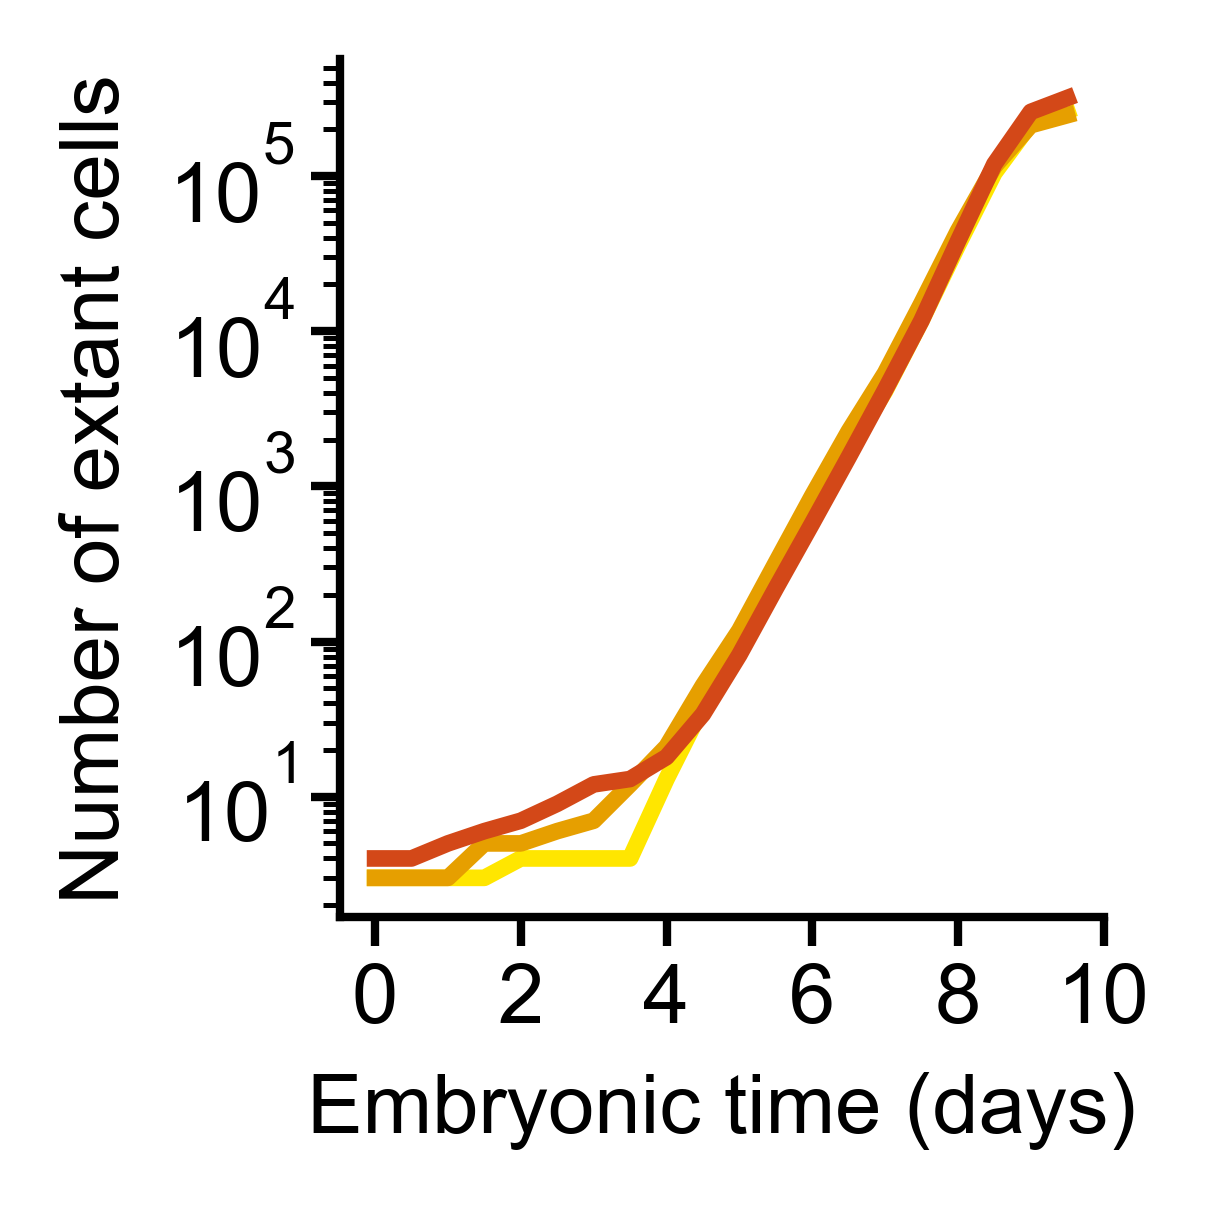

In [227]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(1.9,1.9),dpi=600, layout = "constrained")
sns.lineplot(data=n_extant.query("stage == 'E9.5' & time <= timepoint"), x="time", y="n_extant", hue="embryo", palette=embryo_palette, legend = False)
plt.xticks([0,2,4,6,8,10])

plt.xlabel("Embryonic time (days)")
plt.ylabel("Number of extant cells")
plt.yscale('log')
save_plot(plots_path / "e9.5_growth_kinetics.svg", fig)

## Branches marked by an edit by depth

In [161]:
import numpy as np
import pandas as pd
import networkx as nx

def branch_fraction_by_depth(G, bins=np.arange(0, 10, 0.5), time_key="time"):
    """
    Fraction of branches marked by an edit by depth/time bin.

    Counts edges, not divisions:
    - Every observed edge in the collapsed tree is a marked branch.
    - A multifurcation with k children contributes k-2 hidden unmarked branches.
    - Observed edge time = midpoint of parent and child times.
    - Hidden branch time = midpoint of node time and mean(child times).

    Returns a DataFrame with per-bin marked/total fractions.
    """

    marked_times = []
    hidden_times = []

    # observed branches = actual edges in collapsed tree
    for parent, child in G.edges:
        tp = float(G.nodes[parent][time_key])
        tc = float(G.nodes[child][time_key])
        marked_times.append(0.5 * (tp + tc))
        #marked_times.append(tp)

    # hidden branches from multifurcations
    for n in G.nodes:
        children = list(G.successors(n))
        k = len(children)
        if k > 2:
            tn = float(G.nodes[n][time_key])
            child_times = np.array([float(G.nodes[c][time_key]) for c in children])
            t_hidden = 0.5 * (tn + child_times.mean())
            T = child_times.mean()
            # k-2 hidden branches, spaced on a log(cell-count) scale
            for j in range(1, k - 1):   # j = 1, ..., k-2
                tj = tn + (np.log(j + 1) / np.log(k)) * (T - tn)
                hidden_times.append(tj)

    marked_counts, edges = np.histogram(marked_times, bins=bins)
    hidden_counts, _ = np.histogram(hidden_times, bins=bins)
    total_counts = marked_counts + hidden_counts

    fraction = np.divide(
        marked_counts,
        total_counts,
        out=np.full_like(marked_counts, np.nan, dtype=float),
        where=total_counts > 0
    )

    return pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "bin_center": 0.5 * (edges[:-1] + edges[1:]),
        "marked_branches": marked_counts,
        "hidden_branches": hidden_counts,
        "total_branches": total_counts,
        "pct_marked": fraction * 100,
    })

In [162]:
def fraction_marked_from_tree(G):
    leaves = sum(1 for n in G.nodes if G.out_degree(n) == 0)
    edges = G.number_of_edges()
    return (edges - leaves + 1) / (leaves - 1)

In [168]:
np.arange(0, 11, 1)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [193]:
marked_branches = []
for clone, tree in tdata.obst.items():
    df = branch_fraction_by_depth(tree, bins=[0,2,4,6,7,8,9,10,11])
    marked_branches.append(df.assign(clone = clone))
marked_branches = pd.concat(marked_branches, ignore_index=True)

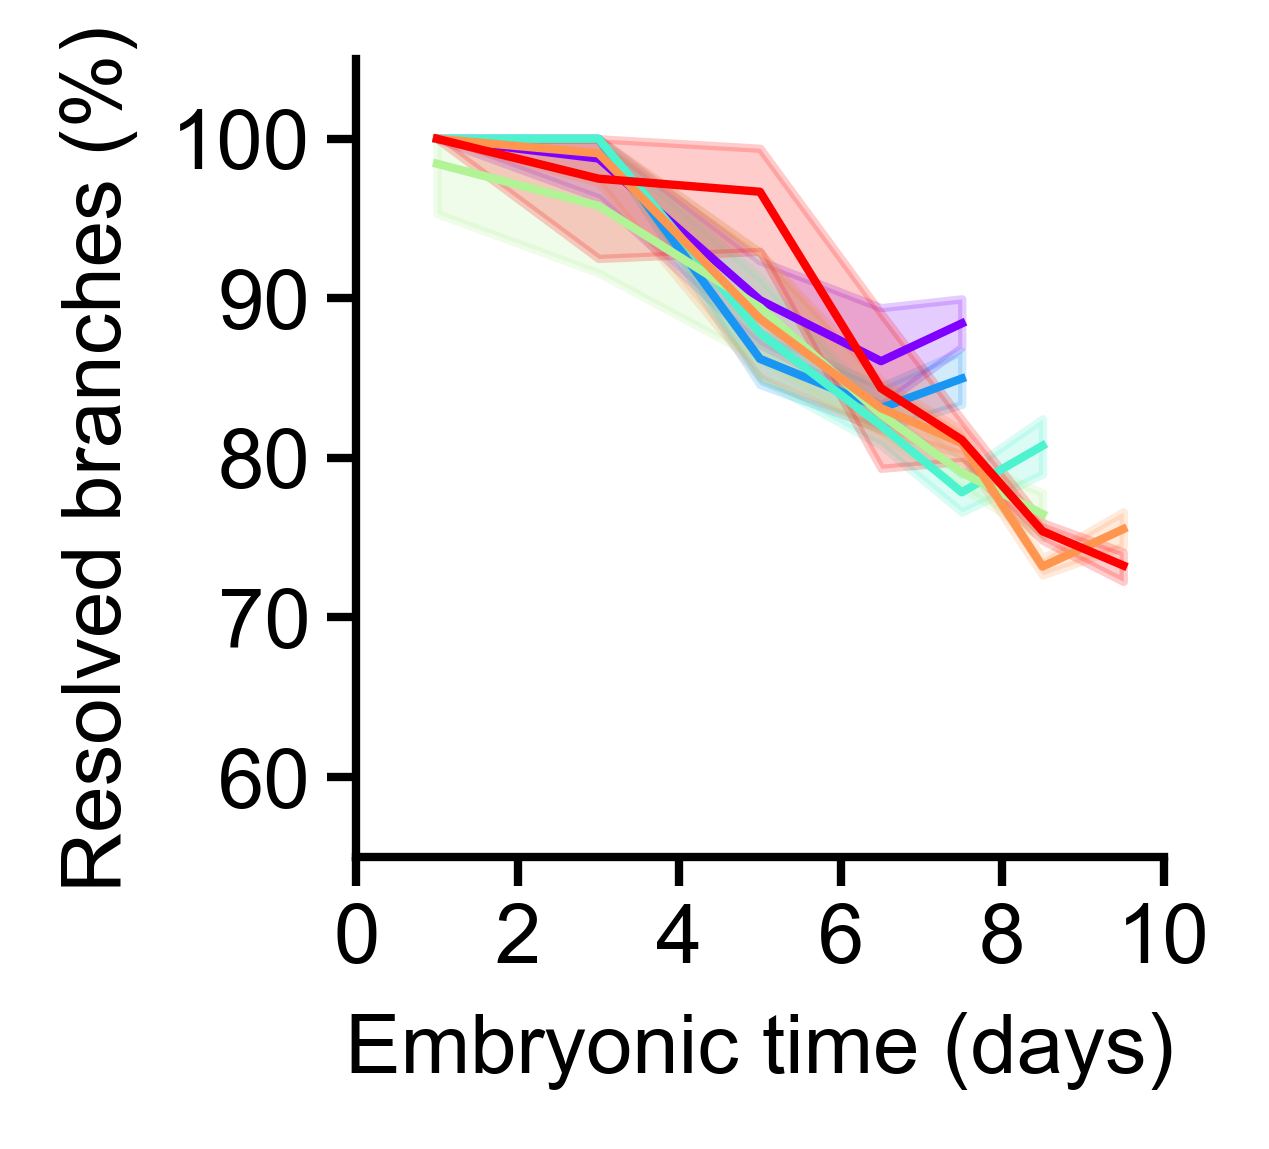

In [194]:
fig, ax = plt.subplots(figsize=(2,1.8),dpi=600, layout = "constrained")
marked_branches["embryo"] = marked_branches["clone"].str.split("-C").str[0]
marked_branches["stage"] = marked_branches["clone"].str.split("-").str[0]
sns.lineplot(data=marked_branches, x="bin_center", y="pct_marked", hue = "stage",palette=stage_palette,legend = False, linewidth = 1)
plt.ylabel("Resolved branches (%)")
plt.xticks([0,2,4,6,8,10])
plt.yticks([60,70,80,90,100])
plt.ylim(55,105)
plt.xlabel("Embryonic time (days)")
save_plot(plots_path / "marked_branches.svg", fig)

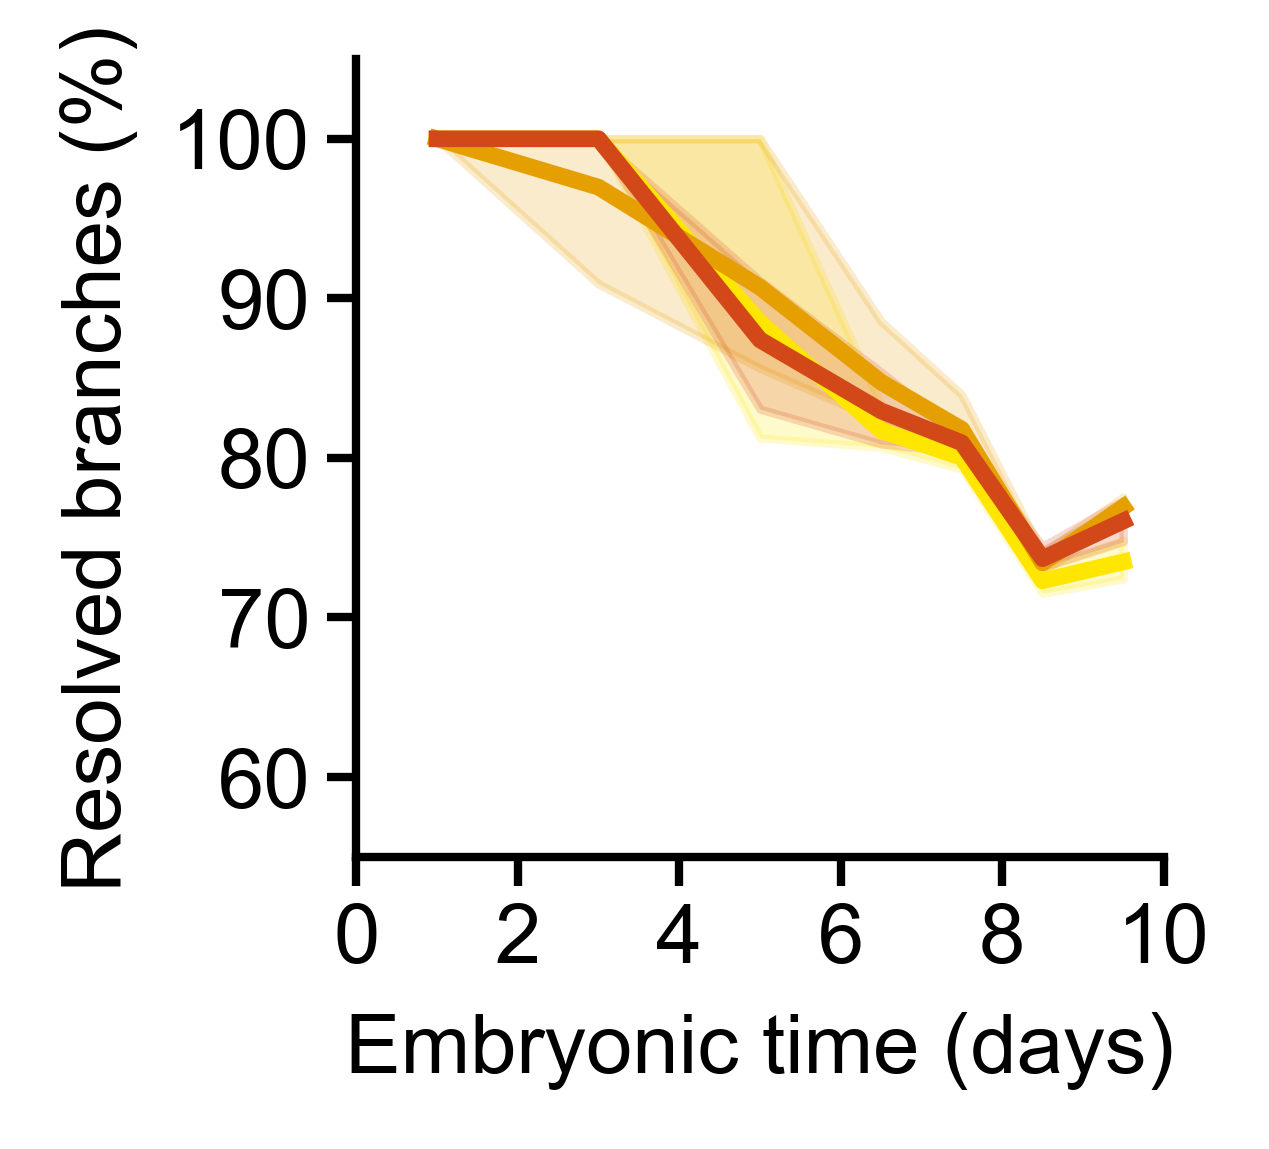

In [198]:
fig, ax = plt.subplots(figsize=(2,1.8),dpi=600, layout = "constrained")
marked_branches["embryo"] = marked_branches["clone"].str.split("-C").str[0]
sns.lineplot(data=marked_branches.query("stage == 'E9.5'"), x="bin_center", y="pct_marked", hue = "embryo",palette=embryo_palette,legend = False)
plt.ylabel("Resolved branches (%)")
plt.xticks([0,2,4,6,8,10])
plt.yticks([60,70,80,90,100])
plt.ylim(55,105)
plt.xlabel("Embryonic time (days)")
save_plot(plots_path / "e9.5_marked_branches.svg", fig)

## PE vs edit fraction

In [200]:
df = tdata.obs.query("type == 'donor'").groupby("subcell_type").agg({"pe_counts": "mean", "edit_frac": "mean","pe_expr": "mean"}).reset_index()

UndefinedVariableError: name 'type' is not defined

In [241]:
embryos = ["e7.5_r1","e7.5_r2","e7.5_r3","e8.0_r1","e8.0_r2","e8.0_r3","e8.5_r1",
    "e8.5_r2","e8.5_r3","e9.0_r1","e9.0_r2","e9.0_r3","e9.5_r1","e9.5_r2","e9.5_r3","e10.0_r1"]
characters = []
for embryo in embryos:
    print(embryo)
    embryo_tdata = td.read_h5td(f"/lab/solexa_weissman/wcolgan/devmap-paper/processing/embryos/{embryo}/{embryo}_tree.h5td")
    characters.append(embryo_tdata.obsm["characters"])
characters = pd.concat(characters, axis=0)

e7.5_r1
e7.5_r2
e7.5_r3
e8.0_r1
e8.0_r2
e8.0_r3
e8.5_r1
e8.5_r2
e8.5_r3
e9.0_r1
e9.0_r2
e9.0_r3
e9.5_r1
e9.5_r2
e9.5_r3
e10.0_r1


In [245]:
saved_characters = characters.copy()

In [246]:
use_obs = tdata.obs_names.intersection(characters.index)
characters = characters.loc[use_obs].copy()

In [250]:

data_path = Path("/lab/solexa_weissman/wcolgan/devmap-paper/data")

In [248]:
characters.to_csv("/lab/wcolgan_scratch/final_characters.csv")

In [251]:
characters.to_csv(data_path / "characters.csv")

In [244]:
use_obs

Index(['E7.5-R1-T1-GGAGTTAGTTCGAGCC-1', 'E7.5-R1-T1-ACCGGATTCCGCAGAT-1',
       'E7.5-R1-T1-TGCTAACGTTAGACGA-1', 'E7.5-R1-T1-AGTGTCATCCTTCAAC-1',
       'E7.5-R1-T1-CTTCAGCCAAGGGATA-1', 'E7.5-R1-T1-TATCGAACATCGGTCT-1',
       'E7.5-R1-T1-AATATCGCAGGGCATC-1', 'E7.5-R1-T1-CAGCTTGGTCAATCGT-1',
       'E7.5-R1-T1-CTGCATTTCGTGCTCC-1', 'E7.5-R1-T1-CAAGGAACAACCTACC-1',
       ...
       'E10.0-R1-T19-GTCTGTCCAACTTCAT-1', 'E10.0-R1-T10-TGGACGTTCTAAGTAC-1',
       'E10.0-R1-T22-ACCCTTTAGGATCTAT-1', 'E10.0-R1-T7-TGCTCACCAGGCATCA-1',
       'E10.0-R1-T3-CGCGCATGTCTAACTA-1', 'E10.0-R1-T8-GTTCCCTGTTCATCCC-1',
       'E10.0-R1-T1-ATCGAACCAGGACTTG-1', 'E10.0-R1-T21-CGTTCAGGTAATGCCT-1',
       'E10.0-R1-T21-GCGTTTCCATGAGTTA-1', 'E10.0-R1-T8-TCTATCTGTAATGGTG-1'],
      dtype='object', length=1449329)

In [ ]:
characters

,intID1039-EMX1,intID1039-HEK3,intID1039-RNF2,intID1068-EMX1,intID1068-HEK3,intID1068-RNF2,intID1070-EMX1,intID1070-HEK3,intID1070-RNF2,intID1113-EMX1,...,intID845-RNF2,intID945-EMX1,intID945-HEK3,intID945-RNF2,intID1423-EMX1,intID1423-HEK3,intID1423-RNF2,intID801-EMX1,intID801-HEK3,intID801-RNF2
cellBC,,,,,,,,,,,,,,,,,,,,,
E7.5-R1-T1-AAACCCGCACTCAGCT-1,*,*,*,*,8,7,5,3,1,3,...,*,*,*,4,NaN,NaN,NaN,NaN,NaN,NaN
E7.5-R1-T1-AAACCCTGTTAGTGTC-1,*,*,*,*,8,6,*,*,8,2,...,*,*,*,7,NaN,NaN,NaN,NaN,NaN,NaN
E7.5-R1-T1-AAACGTCCATGGTCCT-1,*,7,*,*,8,7,*,*,8,5,...,1,7,*,2,NaN,NaN,NaN,NaN,NaN,NaN
E7.5-R1-T1-AAAGTAGTCCAATTCC-1,*,7,1,*,8,7,2,4,*,5,...,1,*,*,2,NaN,NaN,NaN,NaN,NaN,NaN
E7.5-R1-T1-AAAGTTGAGGCTACTA-1,*,7,*,*,5,6,*,*,2,5,...,1,*,*,7,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E10.0-R1-T9-TGTGTTAGTAGCTCGC-1,*,*,*,*,*,*,2,*,7,*,...,3,4,4,3,NaN,NaN,NaN,NaN,NaN,NaN
E10.0-R1-T9-TGTGTTAGTTAATCCA-1,-,-,-,5,*,1,*,*,5,3,...,7,3,2,*,NaN,NaN,NaN,NaN,NaN,NaN
E10.0-R1-T9-TGTGTTGAGAAGGAGA-1,*,*,*,*,*,1,*,*,5,6,...,*,*,2,7,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
use

In [240]:
tdata

TreeData object with n_obs × n_vars = 1795384 × 0
    obs: 'tree', 'embryo', 'stage'
    uns: 'n_extant'
    obsm: 'X_umap'
    obst: 'E7.5-R1-C1', 'E7.5-R1-C2', 'E7.5-R2-C1', 'E7.5-R2-C2', 'E7.5-R2-C3', 'E7.5-R2-C4', 'E7.5-R2-C5', 'E7.5-R2-C6', 'E7.5-R3-C1', 'E7.5-R3-C2', 'E7.5-R3-C3', 'E8.0-R1-C1', 'E8.0-R1-C2', 'E8.0-R1-C3', 'E8.0-R2-C1', 'E8.0-R2-C2', 'E8.0-R3-C1', 'E8.0-R3-C2', 'E8.0-R3-C3', 'E8.0-R3-C4', 'E8.0-R3-C5', 'E8.0-R3-C6', 'E8.5-R1-C1', 'E8.5-R1-C2', 'E8.5-R1-C3', 'E8.5-R1-C4', 'E8.5-R2-C1', 'E8.5-R2-C2', 'E8.5-R3-C1', 'E8.5-R3-C2', 'E8.5-R3-C3', 'E9.0-R1-C1', 'E9.0-R1-C2', 'E9.0-R1-C3', 'E9.0-R1-C4', 'E9.0-R1-C5', 'E9.0-R2-C1', 'E9.0-R2-C2', 'E9.0-R3-C1', 'E9.0-R3-C2', 'E9.5-R1-C1', 'E9.5-R1-C2', 'E9.5-R1-C3', 'E9.5-R2-C1', 'E9.5-R2-C2', 'E9.5-R2-C3', 'E9.5-R3-C1', 'E9.5-R3-C2', 'E9.5-R3-C3', 'E9.5-R3-C4', 'E10.0-R1-C1', 'E10.0-R1-C2', 'E10.0-R1-C3', 'E10.0-R1-C4', 'E10.0-R1-C5', 'E10.0-R1-C6'

In [ ]:
edited = (characters != "-") & (characters != "*")
detected = characters != "-"
edit_frac = edited.sum(axis=1) / detected.sum(axis=1)

In [239]:
pd.concat(characters, axis=0)

,intID1039-EMX1,intID1039-HEK3,intID1039-RNF2,intID1068-EMX1,intID1068-HEK3,intID1068-RNF2,intID1070-EMX1,intID1070-HEK3,intID1070-RNF2,intID1113-EMX1,...,intID709-RNF2,intID845-EMX1,intID845-HEK3,intID845-RNF2,intID945-EMX1,intID945-HEK3,intID945-RNF2,intID1423-EMX1,intID1423-HEK3,intID1423-RNF2
cellBC,,,,,,,,,,,,,,,,,,,,,
E7.5-R1-T1-AAACCCGCACTCAGCT-1,*,*,*,*,8,7,5,3,1,3,...,*,*,*,*,*,*,4,NaN,NaN,NaN
E7.5-R1-T1-AAACCCTGTTAGTGTC-1,*,*,*,*,8,6,*,*,8,2,...,7,*,*,*,*,*,7,NaN,NaN,NaN
E7.5-R1-T1-AAACGTCCATGGTCCT-1,*,7,*,*,8,7,*,*,8,5,...,*,2,8,1,7,*,2,NaN,NaN,NaN
E7.5-R1-T1-AAAGTAGTCCAATTCC-1,*,7,1,*,8,7,2,4,*,5,...,6,2,8,1,*,*,2,NaN,NaN,NaN
E7.5-R1-T1-AAAGTTGAGGCTACTA-1,*,7,*,*,5,6,*,*,2,5,...,6,3,8,1,*,*,7,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E7.5-R3-T1-TGTGAGGAGCCAGACT-1,2,*,*,*,*,*,*,3,4,-,...,*,4,*,2,2,6,3,-,-,-
E7.5-R3-T1-TGTGATTAGCTGGAAG-1,2,*,*,*,7,6,2,*,*,*,...,*,*,*,2,2,6,3,-,-,-
E7.5-R3-T1-TGTGATTAGGCGTCCA-1,2,1,*,*,4,6,*,6,*,*,...,*,*,*,2,2,*,3,!,*,*


In [237]:
characters

[                              intID1039-EMX1 intID1039-HEK3 intID1039-RNF2  \
 cellBC                                                                       
 E7.5-R1-T1-AAACCCGCACTCAGCT-1              *              *              *   
 E7.5-R1-T1-AAACCCTGTTAGTGTC-1              *              *              *   
 E7.5-R1-T1-AAACGTCCATGGTCCT-1              *              7              *   
 E7.5-R1-T1-AAAGTAGTCCAATTCC-1              *              7              1   
 E7.5-R1-T1-AAAGTTGAGGCTACTA-1              *              7              *   
 ...                                      ...            ...            ...   
 E7.5-R1-T1-TGTCGCCTCGACCAAC-1              *              *              *   
 E7.5-R1-T1-TGTGCAATCTAGTACG-1              -              -              -   
 E7.5-R1-T1-TGTGCCAGTGAACTGA-1              *              *              *   
 E7.5-R1-T1-TGTGCCCTCCTCGTGC-1              -              -              -   
 E7.5-R1-T1-TGTGTTGAGGTATGGG-1              *       